## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_psi import *
from funcoes_escoragem import *

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Variáveis Blend4 - Desenvolvimento

In [5]:
# project_id = 'loft-dl-datascience'

# query = '''
# select * from loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527
# '''

# df_raw = pd.read_gbq(query, project_id=project_id)
# df_raw

In [6]:
# df_raw.to_csv(ANALYTICS_DIR/"df_raw_blend4_dev.csv", index=False)

In [7]:
df_raw = pd.read_csv(ANALYTICS_DIR/"df_raw_blend4_dev.csv").drop(columns=["Unnamed: 0"])
df_raw["safra"] = df_raw["requested_at"].astype(str).str[:7]
df_raw = df_raw[df_raw["safra"] <= "2025-08"]
df_raw

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356567,3076092,2025-08-31,2025-08-01,260.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,22.0,1.0,6.0,787.5,8836.5,NaN,NaN,0.0,0.0,2025-08
1356568,3076098,2025-08-31,2025-08-01,346.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,42.0,1.0,1.0,945.0,1233.0,NaN,NaN,0.0,0.0,2025-08
1356569,3076101,2025-08-31,2025-08-01,207.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,24.0,1.0,1.0,651.0,1507.0,NaN,NaN,0.0,0.0,2025-08
1356570,3076108,2025-08-31,2025-08-01,392.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,21.0,1.0,0.0,1627.5,5206.0,NaN,0.110814,0.0,0.0,2025-08


In [8]:
df_dev_blend4 = df_raw.copy()
df_dev_blend4

,contract_id,requested_at,request_month,pred_blend4_1_to_score,predict_blend3_2_to_score,FLAG_TESTE,FLAG_OOT,FLAG_OOT_TARGET_MATURADO,FLAG_COMPARA_MESMA_PROPORCAO_STATUS,status_v2,...,age,property_type,qtde_restricoes__consulta_realizada,rental_value,income,agency_pc4_mais_100_contratos__pc_categorias,city_pc4_mais_100_contratos__pc_categorias,flag_tem__contratos_anteriores,flag_teve_boleto_atrasado__contratos_anteriores,safra
0,1913006,2024-09-01,2024-09-01,503.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,30.0,1.0,NaN,2310.0,4384.0,NaN,NaN,NaN,NaN,2024-09
1,1913007,2024-09-01,2024-09-01,230.0,NaN,1.0,0.0,0.0,NaN,nao_aprovado,...,20.0,1.0,NaN,1942.5,1575.5,NaN,NaN,NaN,NaN,2024-09
2,1913011,2024-09-01,2024-09-01,749.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,0.0,1995.0,42196.0,NaN,0.073830,0.0,0.0,2024-09
3,1913017,2024-09-01,2024-09-01,422.0,NaN,0.0,0.0,0.0,NaN,elegivel_n_ativado,...,33.0,1.0,2.0,1995.0,6507.5,NaN,0.096200,0.0,0.0,2024-09
4,1913018,2024-09-01,2024-09-01,194.0,NaN,0.0,0.0,0.0,NaN,nao_aprovado,...,27.0,1.0,2.0,2730.0,2123.5,NaN,0.138889,0.0,0.0,2024-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356567,3076092,2025-08-31,2025-08-01,260.0,NaN,NaN,1.0,NaN,NaN,elegivel_n_ativado,...,22.0,1.0,6.0,787.5,8836.5,NaN,NaN,0.0,0.0,2025-08
1356568,3076098,2025-08-31,2025-08-01,346.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,42.0,1.0,1.0,945.0,1233.0,NaN,NaN,0.0,0.0,2025-08
1356569,3076101,2025-08-31,2025-08-01,207.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,24.0,1.0,1.0,651.0,1507.0,NaN,NaN,0.0,0.0,2025-08
1356570,3076108,2025-08-31,2025-08-01,392.0,NaN,NaN,1.0,NaN,NaN,nao_aprovado,...,21.0,1.0,0.0,1627.5,5206.0,NaN,0.110814,0.0,0.0,2025-08


In [9]:
bvs = pd.to_numeric(df_dev_blend4["score_proposto__bvs"], errors="coerce")
score = pd.to_numeric(df_dev_blend4["pred_blend4_1_to_score"], errors="coerce")

conditions = [
    bvs <= 334,                         # corte customizado BVS → E
    score.between(763, 1000),           # 763 – 1000
    score.between(704, 762),            # 704 – 762
    score.between(653, 703),            # 653 – 703
    score.between(607, 652),            # 607 – 652
    score.between(562, 606),            # 562 – 606
    score.between(520, 561),            # 520 – 561
    score.between(480, 519),            # 480 – 519
    score.between(443, 479),            # 443 – 479
    score.between(408, 442),            # 408 – 442
    score.between(375, 407),            # 375 – 407
    score.between(343, 374),            # 343 – 374
    score.between(307, 342),            # 307 – 342
    score.between(0, 306),              # 0 – 306
]

choices = [
    "9.E.BVS",      # override BVS ≤ 334
    "1.A+",
    "2.A",
    "2.A",
    "3.B+",
    "3.B+",
    "4.B",
    "4.B",
    "5.C",
    "6.D+",
    "7.D",
    "7.D",
    "8.E",
    "8.E",
]

df_dev_blend4["rating_pol_blend4"] = np.select(conditions, choices, default=None)

## Distribuição Ratings - Salvar

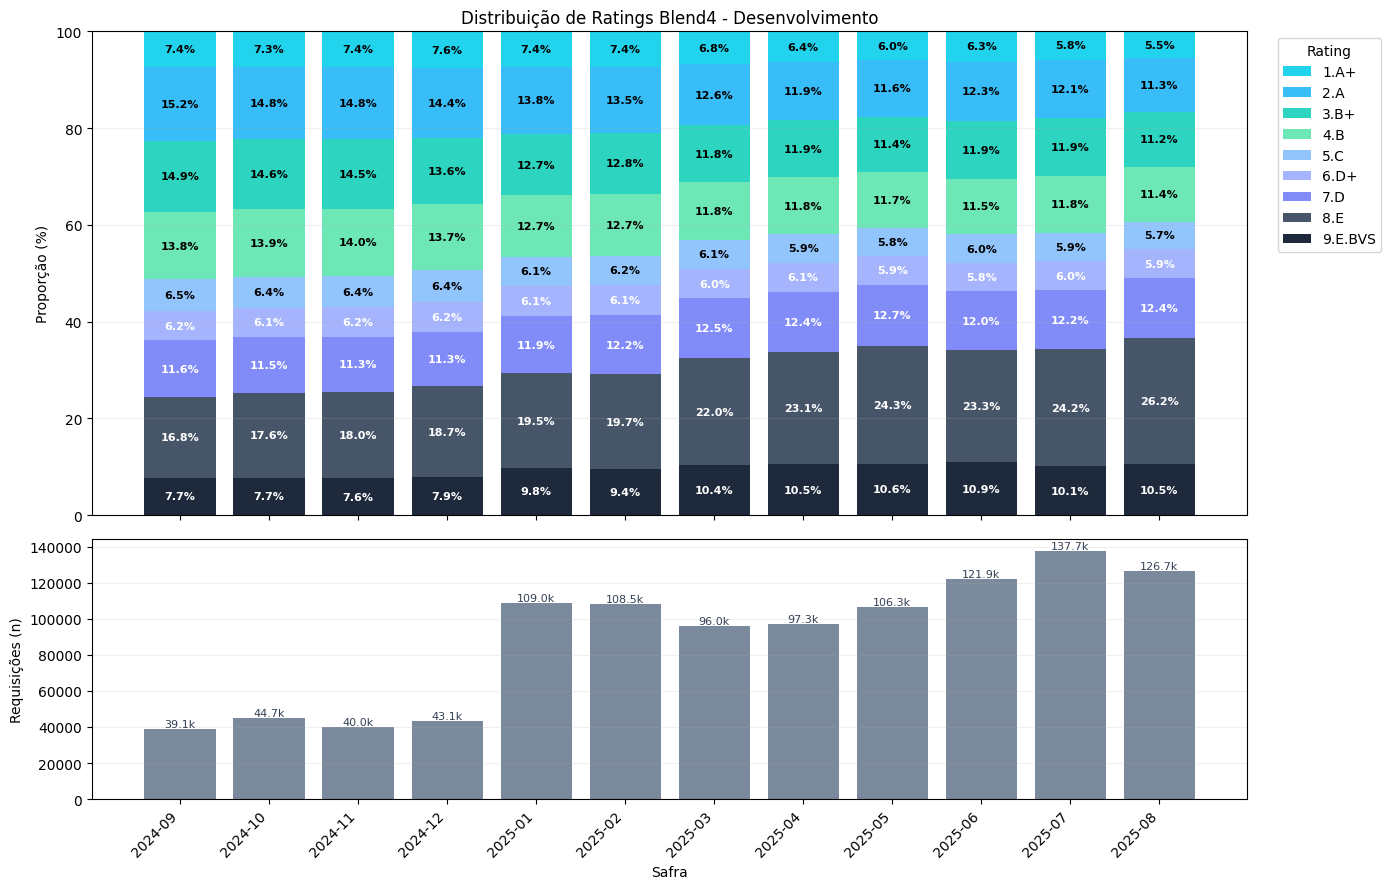

In [10]:
from funcoes_monitoramento import plot_mix_and_volume

RATING_CL_POL_ORDER = [
    "1.A+", "2.A", "3.B+", "4.B", "5.C",
    "6.D+", "7.D", "8.E", "9.E.BVS",
]

RATING_CL_POL_COLOR_MAP = {
    "1.A+": "#22D3EE", "2.A": "#38BDF8", "3.B+": "#2DD4BF",
    "4.B": "#6EE7B7", "5.C": "#93C5FD", "6.D+": "#A5B4FC",
    "7.D": "#818CF8", "8.E": "#475569", "9.E.BVS": "#1E293B",
}

RATING_CL_POL_TEXT_COLOR_MAP = {
    "1.A+": "black", "2.A": "black", "3.B+": "black",
    "4.B": "black", "5.C": "black", "6.D+": "white",
    "7.D": "white", "8.E": "white", "9.E.BVS": "white",
}

plot_df = df_dev_blend4.dropna(subset=["rating_pol_blend4", "safra"]).copy()
plot_df["safra"] = plot_df["safra"].astype(str)
safra_order = sorted(plot_df["safra"].unique())

pct_df = (
    pd.crosstab(plot_df["safra"], plot_df["rating_pol_blend4"], normalize="index")
    .mul(100)
    .reindex(index=safra_order)
    .reindex(columns=RATING_CL_POL_ORDER, fill_value=0)
)

volume = plot_df.groupby("safra").size().reindex(safra_order, fill_value=0)

plot_mix_and_volume(
    pct_df,
    volume,
    title="Distribuição de Ratings Blend4 - Desenvolvimento",
    xlabel="Safra",
    category_order=RATING_CL_POL_ORDER,
    color_map=RATING_CL_POL_COLOR_MAP,
    text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Rating",
    min_label_pct=3.0,
)
plt.show()

In [11]:
pct_df

rating_pol_blend4,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E.BVS
safra,,,,,,,,,
2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746
2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185
2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311
2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281
2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168
2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361
2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723
2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915
2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488


In [12]:
df = pct_df.join(pd.DataFrame(volume).rename(columns={0: "volume"}), on="safra", how="left")
df

,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E.BVS,volume
safra,,,,,,,,,,
2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746,39121
2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185,44731
2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311,40001
2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281,43060
2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168,109011
2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361,108527
2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723,96018
2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915,97266
2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488,106310


In [13]:
df.to_csv(ANALYTICS_DIR/"dev_rating_pol_blend4.csv")

## Restrição BVS e Preparação de Variáveis

In [14]:
df_dev_blend4 = df_dev_blend4[df_dev_blend4["score_proposto__bvs"] > 334]
# df_predict = prepare_blend4_variables(df_dev_blend4)
# df_predict = predict_blend4_1(df_predict_vars)

## Base Blend4 em Produção

In [28]:
df_prod = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
df_prod = df_prod[df_prod["message_decisao"] == "BLEND_4"].copy()
df_prod

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4
204,12805466462,4288262,2026-06-23,2026-07-06,1,NI,BLEND_4,6049743,33,12805466462,...,-0.40,0.0,1.660741,0.00000,0.007242,0.722146,278.0,E,E,E-2.E
544,58606855804,4324431,2026-07-02,2026-07-03,1,D,BLEND_4,6045740,33,58606855804,...,-0.40,1.0,2.121407,-0.12931,-2.756127,0.707092,293.0,E,E,E-2.E
619,6059361374,4331865,2026-07-03,2026-07-03,1,NI,BLEND_4,6045784,32,6059361374,...,-0.15,3.0,-0.580162,-0.12931,1.883000,0.554473,446.0,B,B,8.C
629,14873319757,4333099,2026-07-04,2026-07-04,1,NI,BLEND_4,6047352,36,14873319757,...,-0.05,2.0,-0.201120,0.00000,-0.748651,0.608675,391.0,D,D,10.D
659,42383901806,4336590,2026-07-06,2026-07-06,1,F,BLEND_4,6051614,33,42383901806,...,-0.10,5.0,-0.304770,0.00000,-0.507195,0.720352,280.0,E,E,E-2.E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112736,12097137997,4377028,2026-07-15,2026-07-15,1,NI,BLEND_4,6101662,33,12097137997,...,-0.50,1.0,2.409324,0.00000,-0.676309,0.660688,339.0,E,E,E-1.E
112738,2963615850,4377321,2026-07-15,2026-07-15,1,NI,BLEND_4,6102051,31,2963615850,...,1.70,0.0,1.274204,0.00000,0.768522,0.462449,538.0,A,A,6.B
112745,27655926832,4377857,2026-07-15,2026-07-15,1,NI,BLEND_4,6102699,36,27655926832,...,0.60,1.0,3.447569,0.00000,-0.348689,0.605641,394.0,D,D,10.D
112747,2832352685,4378086,2026-07-15,2026-07-15,1,F,BLEND_4,6102971,31,2832352685,...,2.20,0.0,0.610619,0.00000,1.065538,0.468938,531.0,A,A,6.B


In [29]:
# df_prod["safra"] = df_prod["requested_at"].astype(str).str[:7]
df_prod.groupby(df_prod["requested_at"].astype(str).str[:7]).size()


requested_at
2026-06      56
2026-07    5903
dtype: int64

## PSI de Variáveis: Treino/Teste e OOT

In [17]:
# model_vars = [
#     "score_proposto__bvs__normalized4_1",
#     "SERASA_CHSV5__normalized4_1",
#     "age__normalized4_1",
#     "property_type",
#     "qtde_restricoes__consulta_realizada__normalized4_1",
#     "income_commitment__normalized4_1",
#     "agency_pc4_mais_100_contratos__pc_categorias__normalized4_1",
#     "city_pc4_mais_100_contratos__pc_categorias__normalized4_1",
#     "flag_tem__contratos_anteriores",
#     "flag_teve_boleto_atrasado__contratos_anteriores",
#     "agency_pc4_mais_100_contratos__pc_categorias_is_null",
#     "city_pc4_mais_100_contratos__pc_categorias_is_null",
#     "pred_blend4_1_to_score",
# ]

In [18]:
model_vars = [
    "score_proposto__bvs",
    "SERASA_CHSV5",
    "age",
    "property_type",
    "qtde_restricoes__consulta_realizada",
    "income_commitment",
    "agency_pc4_mais_100_contratos__pc_categorias",
    "city_pc4_mais_100_contratos__pc_categorias",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "pred_blend4_1_to_score",
]

In [22]:
df = df_dev_blend4.copy()

In [ ]:
df["income_commitment"] = df["rental_value"] / df["income"]
df["income_commitment"] = df["income_commitment"].replace([np.inf, -np.inf], np.nan)

fill_dict_blend4_1 = ({
    "agency_pc4_mais_100_contratos__pc_categorias": 0.12931034482758633,
    "city_pc4_mais_100_contratos__pc_categorias": 0.10233029381965561,
    "property_type": 1,
    "flag_tem__contratos_anteriores": 0,
    "flag_teve_boleto_atrasado__contratos_anteriores": 0,
})

cols_flag = [
    "city_pc4_mais_100_contratos__pc_categorias",
    "agency_pc4_mais_100_contratos__pc_categorias",
]

for col in cols_flag:
    df[f"{col}_is_null"] = df[col].isna().astype(int)

# Null flags (before imputation)
df = df.fillna(fill_dict_blend4_1)

In [21]:
from funcoes_psi import (
    calculate_development_psi_baselines,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

train_mask = df_dev_blend4["FLAG_TESTE"] == 0
test_mask = df_dev_blend4["FLAG_TESTE"] == 1
oot_mask = df_dev_blend4["FLAG_OOT"] == 1

psi_baseline_long, psi_reference_artifact = calculate_development_psi_baselines(
    df=df,
    variables=model_vars,
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "FLAG_TESTE == 0",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
4,city_pc4_mais_100_contratos__pc_categorias,0.054503,0.000085
9,pred_blend4_1_to_score,0.023760,0.000040
11,qtde_restricoes__consulta_realizada,0.023589,0.000028
0,SERASA_CHSV5,0.020552,0.000130
12,score_proposto__bvs,0.010233,0.000116
2,agency_pc4_mais_100_contratos__pc_categorias,0.005090,0.000026
10,property_type,0.002975,0.000004
3,agency_pc4_mais_100_contratos__pc_categorias_i...,0.001303,0.000000
1,age,0.001148,0.000071
8,income_commitment,0.000865,0.000048


In [22]:
# from funcoes_psi import (
#     calculate_development_psi_baselines,
#     pivot_psi_baseline,
#     save_psi_reference,
#     BINARY_MODEL_VARS,
# )

# train_mask = df_dev_blend4["FLAG_TESTE"] == 0
# test_mask = df_dev_blend4["FLAG_TESTE"] == 1
# oot_mask = df_dev_blend4["FLAG_OOT"] == 1

# psi_baseline_long, psi_reference_artifact = calculate_development_psi_baselines(
#     df=df_predict,
#     variables=model_vars,
#     train_mask=train_mask,
#     test_mask=test_mask,
#     oot_mask=oot_mask,
#     n_bins=10,
#     binary_vars=BINARY_MODEL_VARS,
#     metadata={
#         "model": "blend4_1",
#         "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
#         "reference_split": "FLAG_TESTE == 0",
#         "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
#     },
# )

# psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
# psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

## Salvar Artefatos

In [23]:
df.groupby(["safra", "FLAG_OOT"]).size()

safra    FLAG_OOT
2024-09  0.0          36108
2024-10  0.0          41275
2024-11  0.0          36974
2024-12  0.0          39659
2025-01  0.0          98343
2025-02  0.0          98286
2025-03  0.0          86066
2025-04  1.0          87023
2025-05  1.0          95047
2025-06  1.0         108596
2025-07  1.0         123807
2025-08  1.0         113375
dtype: int64

In [24]:
from funcoes_psi import (
    calculate_development_psi_baselines_final,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

psi_reference_artifact = calculate_development_psi_baselines_final(
    df=df[df["FLAG_OOT"]==1],
    variables=model_vars,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_1",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Treino_Teste_OOT",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
4,city_pc4_mais_100_contratos__pc_categorias,0.054503,0.000085
9,pred_blend4_1_to_score,0.023760,0.000040
11,qtde_restricoes__consulta_realizada,0.023589,0.000028
0,SERASA_CHSV5,0.020552,0.000130
12,score_proposto__bvs,0.010233,0.000116
2,agency_pc4_mais_100_contratos__pc_categorias,0.005090,0.000026
10,property_type,0.002975,0.000004
3,agency_pc4_mais_100_contratos__pc_categorias_i...,0.001303,0.000000
1,age,0.001148,0.000071
8,income_commitment,0.000865,0.000048


In [25]:
# from funcoes_psi import (
#     calculate_development_psi_baselines_final,
#     pivot_psi_baseline,
#     save_psi_reference,
#     BINARY_MODEL_VARS,
# )

# psi_reference_artifact = calculate_development_psi_baselines_final(
#     df=df_predict,
#     variables=model_vars,
#     n_bins=10,
#     binary_vars=BINARY_MODEL_VARS,
#     metadata={
#         "model": "blend4_1",
#         "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
#         "reference_split": "Treino_Teste_OOT",
#         "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
#     },
# )

# psi_baseline_ref = pivot_psi_baseline(psi_baseline_long)
# psi_baseline_ref.sort_values("psi_oot_vs_train_ref", ascending=False)

In [26]:
# Save single artifact + baseline table
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_psi_reference.pkl"
PSI_BASELINE_PATH = ANALYTICS_DIR / "blend4_psi_baseline_ref.csv"

save_psi_reference(psi_reference_artifact, PSI_REFERENCE_PATH)
psi_baseline_ref.to_csv(PSI_BASELINE_PATH, index=False)

print(f"Saved artifact: {PSI_REFERENCE_PATH}")
print(f"Saved baseline: {PSI_BASELINE_PATH}")

Saved artifact: data/analytics/blend4_psi_reference.pkl
Saved baseline: data/analytics/blend4_psi_baseline_ref.csv


In [27]:
psi_reference_artifact["variables"]["agency_pc4_mais_100_contratos__pc_categorias"]

{'type': 'quantile',
 'edges': [-inf, 0.12931034482758633, inf],
 'bin_labels': ['(-inf, 0.129310]', '(0.129310, inf]'],
 'expected_counts': {'(-inf, 0.129310]': 475521, '(0.129310, inf]': 52327}}

## Avaliação PSI-Produção

In [28]:
psi_df = calculate_psi_table_from_reference(
    df_actual=df_prod,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)
psi_df

,variable,comparison,psi,status,n_actual
0,SERASA_CHSV5,production_vs_train,4.742114,unstable,111759
1,score_proposto__bvs,production_vs_train,4.695184,unstable,111759
2,pred_blend4_1_to_score,production_vs_train,2.249395,unstable,111759
3,income_commitment,production_vs_train,0.169555,moderate,111759
4,age,production_vs_train,0.166137,moderate,111759
5,city_pc4_mais_100_contratos__pc_categorias,production_vs_train,0.075082,stable,111759
6,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.026021,stable,111759
7,agency_pc4_mais_100_contratos__pc_categorias,production_vs_train,0.002034,stable,111759
8,agency_pc4_mais_100_contratos__pc_categorias_i...,production_vs_train,0.001154,stable,111759
9,qtde_restricoes__consulta_realizada,production_vs_train,0.001086,stable,111759


## Artefato Exclusivo BVS

In [29]:
df_bvs = df_raw.copy()
df_bvs["SCORE_BVS"] = df_bvs["score_proposto__bvs"]

In [30]:
train_mask = df_bvs["FLAG_TESTE"] == 0
test_mask = df_bvs["FLAG_TESTE"] == 1
oot_mask = df_bvs["FLAG_OOT"] == 1

psi_baseline_long_bvs, psi_reference_artifact_bvs = calculate_development_psi_baselines(
    df=df_bvs,
    variables=["score_proposto__bvs"],
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "bvs_score",
        "variable": "score_proposto__bvs",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "FLAG_TESTE == 0",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_bvs = pivot_psi_baseline(psi_baseline_long_bvs)
psi_baseline_ref_bvs

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,score_proposto__bvs,0.011354,0.000099


In [31]:
from funcoes_psi import (
    calculate_development_psi_baselines_final,
    pivot_psi_baseline,
    save_psi_reference,
    BINARY_MODEL_VARS,
)

psi_reference_artifact_bvs = calculate_development_psi_baselines_final(
    df=df_bvs[df_bvs["FLAG_OOT"]==1],
    variables=["SCORE_BVS"],
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "blend4_score_bvs",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "BVS_Score_Treino_Teste_OOT",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_bvs = pivot_psi_baseline(psi_baseline_long_bvs)
psi_baseline_ref_bvs

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,score_proposto__bvs,0.011354,0.000099


In [32]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_bvs_score_psi_reference.pkl"
save_psi_reference(psi_reference_artifact_bvs, PSI_REFERENCE_PATH)
print(f"Saved artifact: {PSI_REFERENCE_PATH}")

Saved artifact: data/analytics/blend4_bvs_score_psi_reference.pkl


## Artefato Renda e Aluguel

In [33]:
train_mask = df_raw["FLAG_TESTE"] == 0
test_mask = df_raw["FLAG_TESTE"] == 1
oot_mask = df_raw["FLAG_OOT"] == 1

psi_baseline_long_raw, psi_reference_artifact_raw = calculate_development_psi_baselines(
    df=df_raw,
    variables=["rental_value", "income"],
    train_mask=train_mask,
    test_mask=test_mask,
    oot_mask=oot_mask,
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "Blend4_Raw",
        "variable": "Renda e Aluguel",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Desenvolvimento",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_raw = pivot_psi_baseline(psi_baseline_long_raw)
psi_baseline_ref_raw

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,income,0.001103,0.000081
1,rental_value,0.003353,0.000068


In [34]:
psi_reference_artifact_raw = calculate_development_psi_baselines_final(
    df=df_raw[df_raw["FLAG_OOT"]==1],
    variables=["rental_value", "income"],
    n_bins=10,
    binary_vars=BINARY_MODEL_VARS,
    metadata={
        "model": "Blend4_Raw",
        "variable": "Renda e Aluguel",
        "reference_dataset": "loft-dl-datascience.ds_risk_cp.blend4_variaveis_predict_20260527",
        "reference_split": "Desenvolvimento",
        "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    },
)

psi_baseline_ref_raw = pivot_psi_baseline(psi_baseline_long_raw)
psi_baseline_ref_raw

comparison,variable,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,income,0.001103,0.000081
1,rental_value,0.003353,0.000068


In [35]:
psi_df = calculate_psi_table_from_reference(
    df_actual=df_prod,
    artifact=psi_reference_artifact_raw,
    comparison_label="production_vs_development",
    variables=["rental_value", "income"],
)
psi_df

,variable,comparison,psi,status,n_actual
0,income,production_vs_development,0.127211,moderate,111759
1,rental_value,production_vs_development,0.069280,stable,111759


In [36]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "psi_income_rental_reference.pkl"
save_psi_reference(psi_reference_artifact_raw, PSI_REFERENCE_PATH)
print(f"Saved artifact: {PSI_REFERENCE_PATH}")

Saved artifact: data/analytics/psi_income_rental_reference.pkl


## Avaliar Renda e Aluguel em valores Brutos

In [45]:
VARS = ["rental_value", "income", "income_commitment", "city_pc4_mais_100_contratos__pc_categorias"]
PERCENTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
PERCENTILE_COLS = [f"{p}%" for p in range(10, 100, 10)]


def ensure_income_commitment(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    if "income_commitment" not in out.columns:
        out["income_commitment"] = out["rental_value"] / out["income"]
        out["income_commitment"] = out["income_commitment"].replace([np.inf, -np.inf], np.nan)
    return out


def plot_percentiles_by_month(d: pd.DataFrame, date_col: str, dataset_name: str):
    d = ensure_income_commitment(d)
    d = d.copy()
    d["mes"] = pd.to_datetime(d[date_col].astype(str).str[:7] + "-01")

    for var in VARS:
        summary = (
            d.groupby("mes")[var]
            .describe(percentiles=PERCENTILES)
            .round(4)
        )

        plot_df = summary[PERCENTILE_COLS].copy().sort_index()

        ax = plot_df.plot(figsize=(12, 6), marker="o", linewidth=2)
        ax.set_xlabel("Mês de referência")
        ax.set_ylabel(var)
        ax.set_title(f"Percentis da variável por mês — {dataset_name}\n{var}")
        ax.grid(alpha=0.3)
        ax.legend(title="Percentil", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

In [53]:
df_dev_blend4["income_commitment"] = df_dev_blend4["rental_value"] / df_dev_blend4["income"]
df_dev_blend4["income_commitment"] = df_dev_blend4["income_commitment"].replace([np.inf, -np.inf], np.nan)

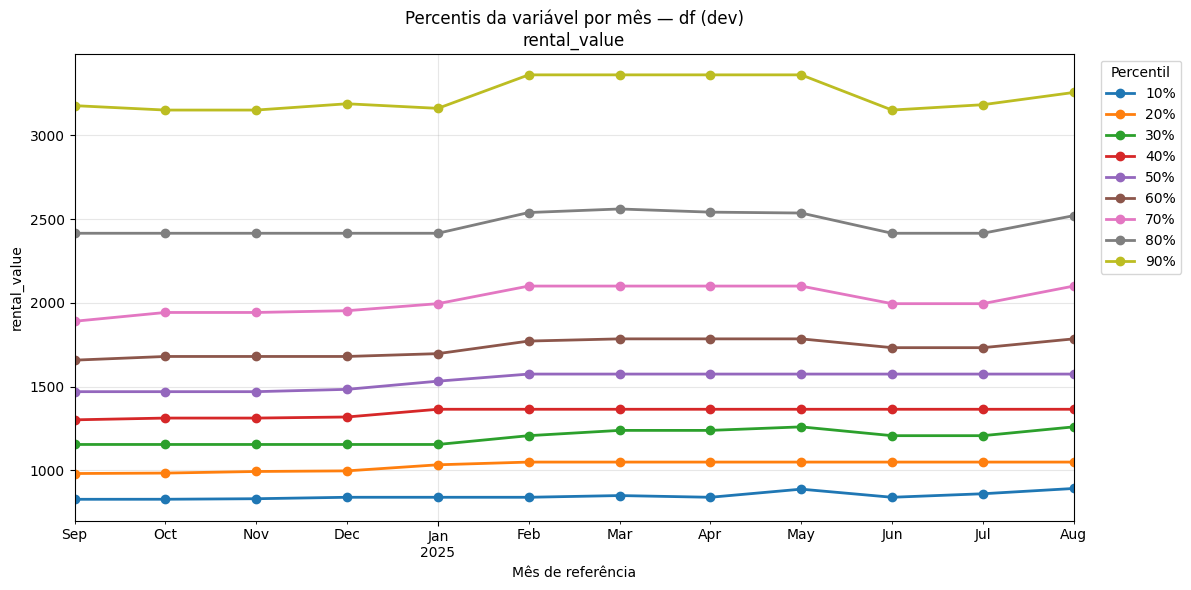

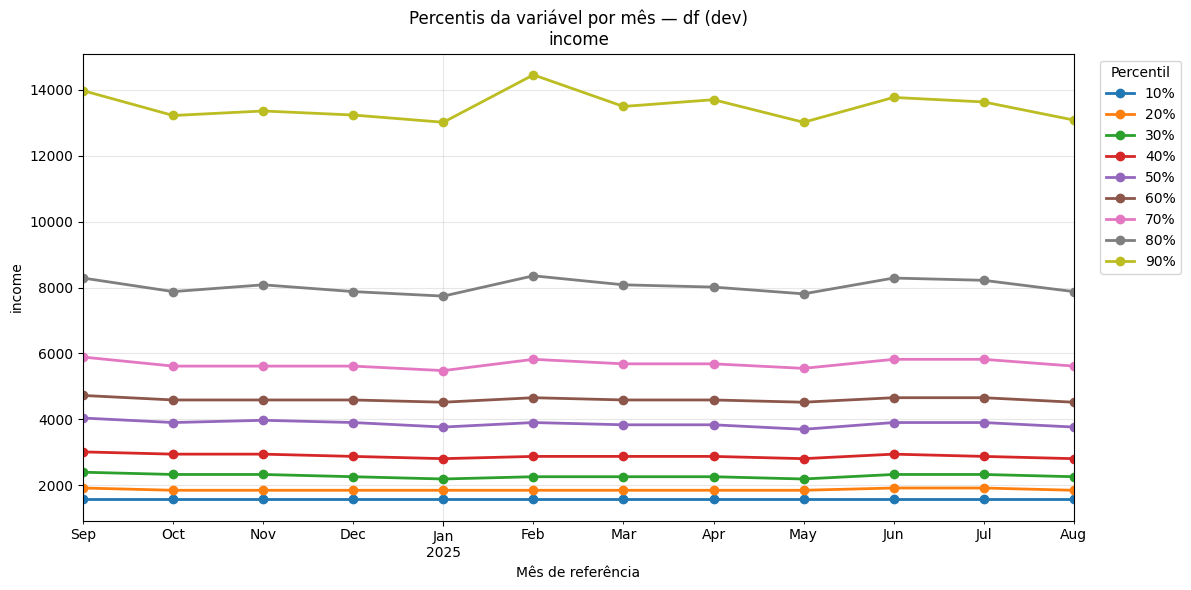

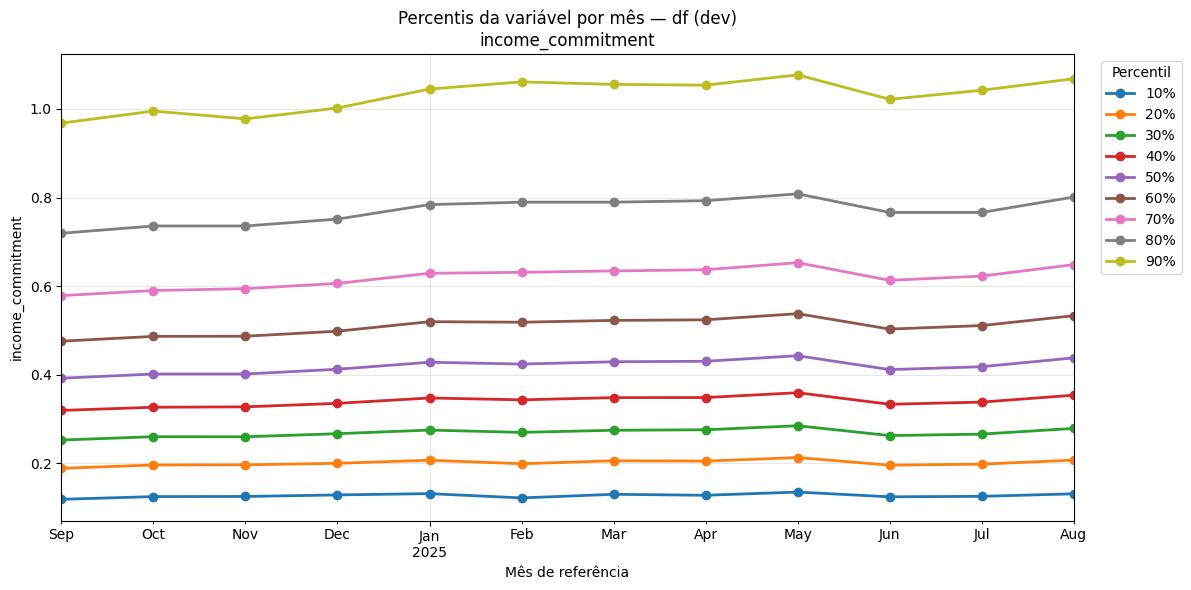

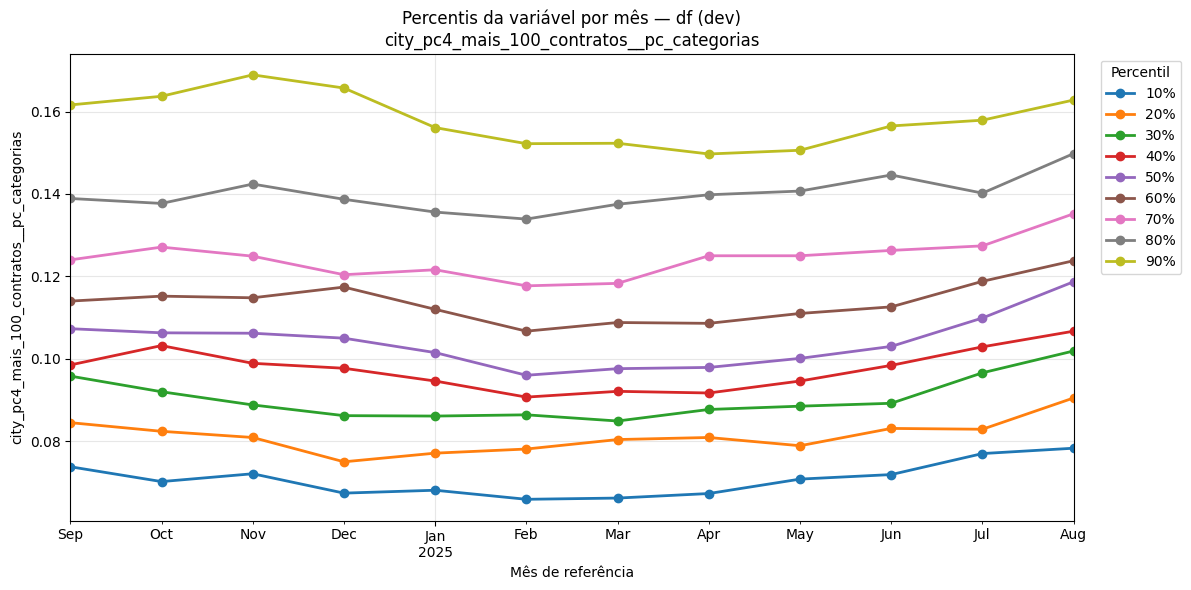

In [54]:
# Desenvolvimento
plot_percentiles_by_month(df_dev_blend4, date_col="safra", dataset_name="df (dev)")

In [41]:
df_rec = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")
df_rec["safra"] = df_rec["requested_at"].astype(str).str[:7]
df_rec = df_rec[df_rec["message_decisao"].isin(["BLEND_4", "BLEND3_3"])].copy()

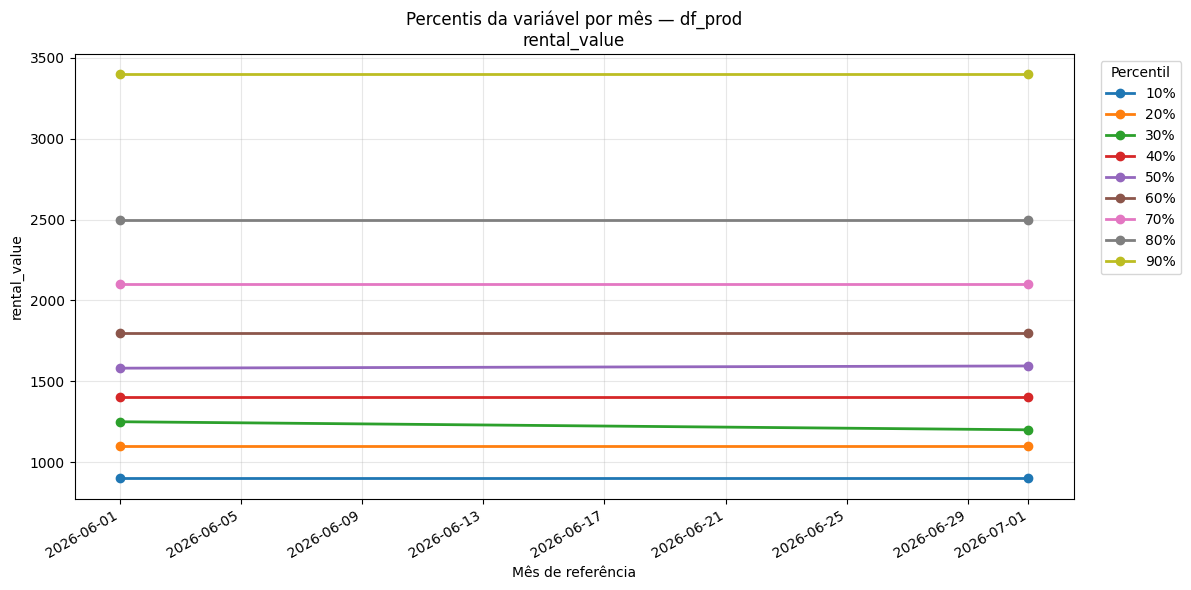

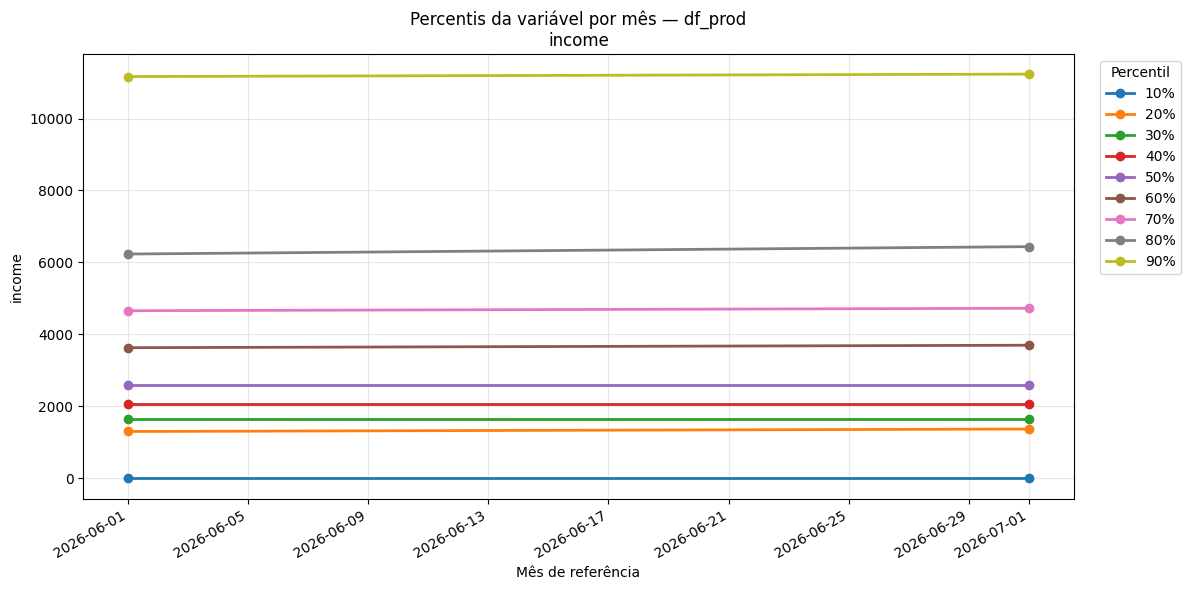

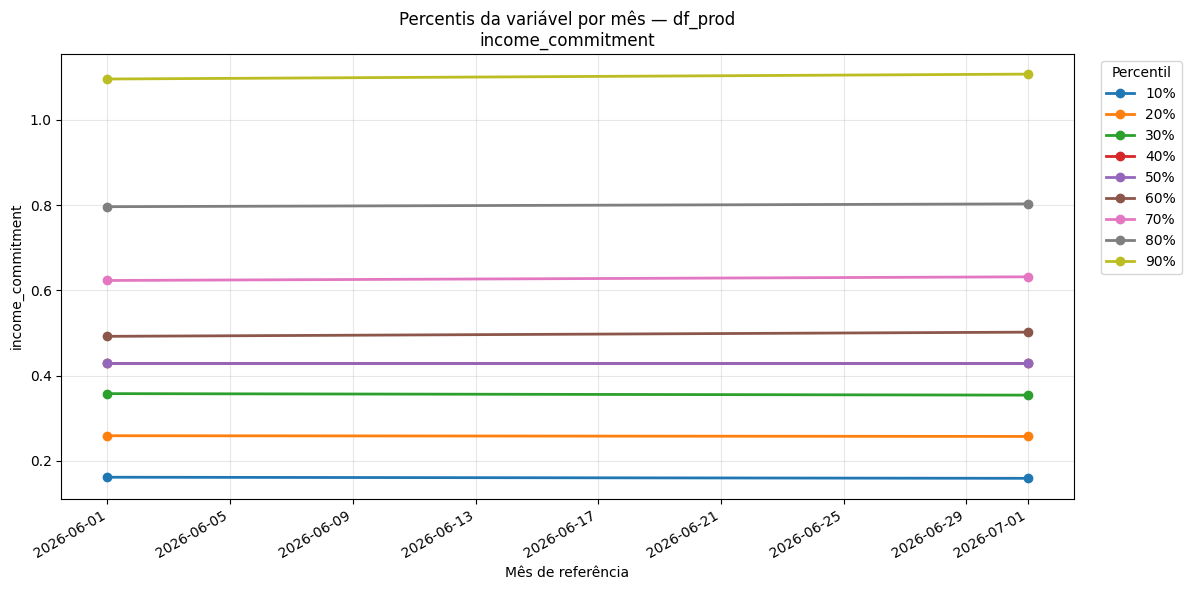

In [44]:
# Produção (mesma lógica que você já usa com requested_at)
# df_prod_plot = df_prod[df_prod["income"] > 0].copy()
plot_percentiles_by_month(df_rec, date_col="safra", dataset_name="df_prod")

In [31]:
df[["rental_value", "income", "income_commitment"]].describe()

,rental_value,income,income_commitment
count,964559.000000,964559.000000,964559.000000
mean,1924.498164,7310.812823,0.536164
std,1449.515413,13050.017738,0.481497
min,1.050000,479.500000,0.000028
25%,1103.865000,2055.000000,0.236096
50%,1575.000000,3836.000000,0.422854
75%,2205.000000,6644.500000,0.696749
max,20895.000000,184881.500000,15.671341


In [25]:
df_prod[["rental_value", "income", "income_commitment"]].describe()

,rental_value,income,income_commitment,age
count,1.121450e+05,112145.000000,1.121450e+05,112145.000000
mean,2.184786e+09,6247.695372,4.088986e+05,37.083579
std,7.316255e+11,14026.757729,1.369316e+08,13.721655
min,1.350000e+00,0.000000,3.261487e-05,0.000000
25%,1.200000e+03,1575.500000,2.943254e-01,28.000000
50%,1.600000e+03,2740.000000,4.299448e-01,34.000000
75%,2.300000e+03,5548.500000,6.951686e-01,44.000000
max,2.450072e+14,219268.500000,4.585573e+10,96.000000



=== rental_value ===
Decil 01: (-inf, 840.0000]
Decil 02: (840.0000, 1050.0000]
Decil 03: (1050.0000, 1207.5000]
Decil 04: (1207.5000, 1365.0000]
Decil 05: (1365.0000, 1575.0000]
Decil 06: (1575.0000, 1732.5000]
Decil 07: (1732.5000, 2016.0000]
Decil 08: (2016.0000, 2488.5000]
Decil 09: (2488.5000, 3265.5000]
Decil 10: (3265.5000, inf]

=== income ===
Decil 01: (-inf, 1575.5000]
Decil 02: (1575.5000, 1849.5000]
Decil 03: (1849.5000, 2260.5000]
Decil 04: (2260.5000, 2877.0000]
Decil 05: (2877.0000, 3836.0000]
Decil 06: (3836.0000, 4589.5000]
Decil 07: (4589.5000, 5685.5000]
Decil 08: (5685.5000, 8014.5000]
Decil 09: (8014.5000, 13494.5000]
Decil 10: (13494.5000, inf]

=== income_commitment ===
Decil 01: (-inf, 0.1274]
Decil 02: (0.1274, 0.2020]
Decil 03: (0.2020, 0.2705]
Decil 04: (0.2705, 0.3429]
Decil 05: (0.3429, 0.4229]
Decil 06: (0.4229, 0.5132]
Decil 07: (0.5132, 0.6271]
Decil 08: (0.6271, 0.7771]
Decil 09: (0.7771, 1.0451]
Decil 10: (1.0451, inf]

=== age ===
Decil 01: (-inf, 22

,variable,bin_label,expected_count,actual_count,expected_pct,actual_pct,delta_pct
0,rental_value,"(-inf, 840.000000]",100746,6230,10.44,6.68,-3.76
1,rental_value,"(840.000000, 1050.000000]",130483,10569,13.53,11.33,-2.20
2,rental_value,"(1050.000000, 1207.500000]",63920,9346,6.63,10.01,3.38
3,rental_value,"(1207.500000, 1365.000000]",108741,6921,11.27,7.42,-3.85
4,rental_value,"(1365.000000, 1575.000000]",120864,11228,12.53,12.03,-0.50
5,rental_value,"(1575.000000, 1732.500000]",56317,7702,5.84,8.25,2.41
6,rental_value,"(1732.500000, 2016.000000]",94246,11084,9.77,11.88,2.11
7,rental_value,"(2016.000000, 2488.500000]",96339,7913,9.99,8.48,-1.51
8,rental_value,"(2488.500000, 3265.500000]",96454,11194,10.00,11.99,1.99
9,rental_value,"(3265.500000, inf]",96449,11136,10.00,11.93,1.93


,variable,psi
0,rental_value,0.073118
1,income,0.010162
2,income_commitment,0.015588
3,age,0.000991
4,city_pc4_mais_100_contratos__pc_categorias,0.083996


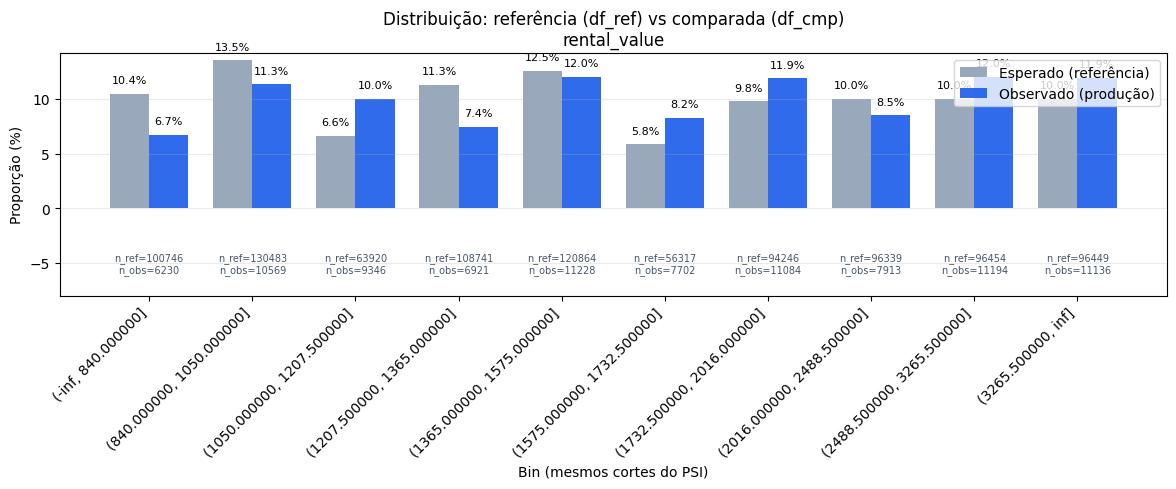

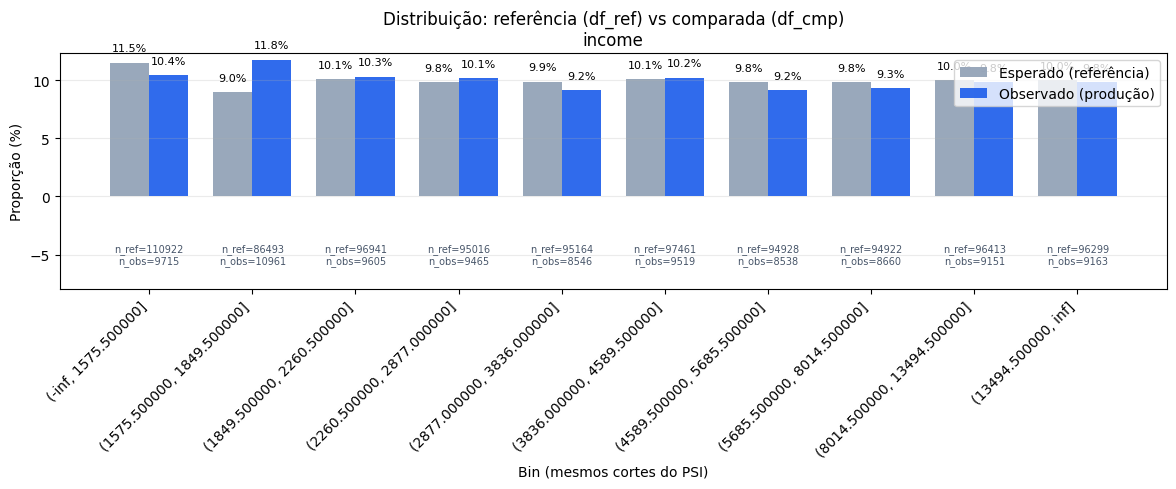

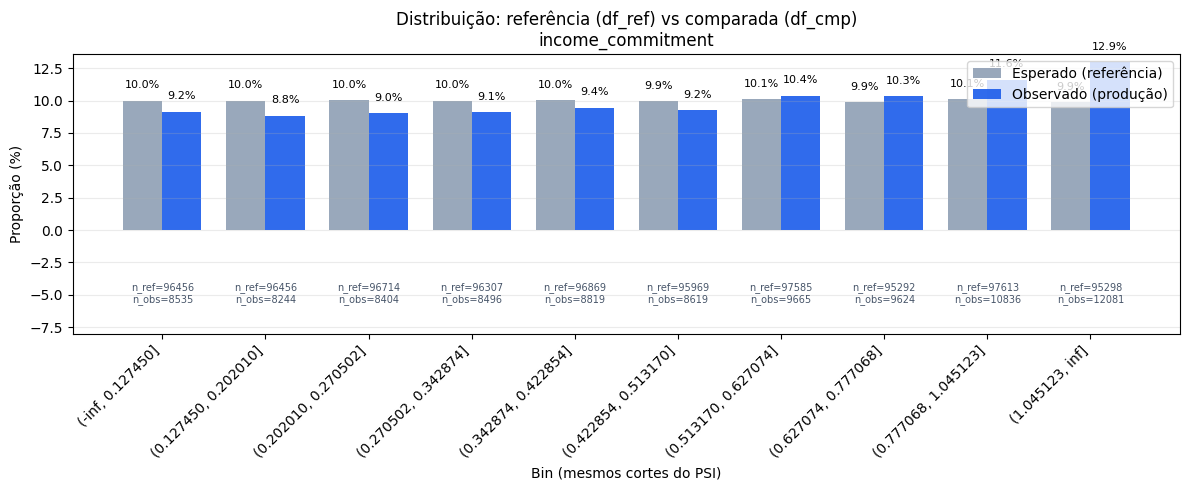

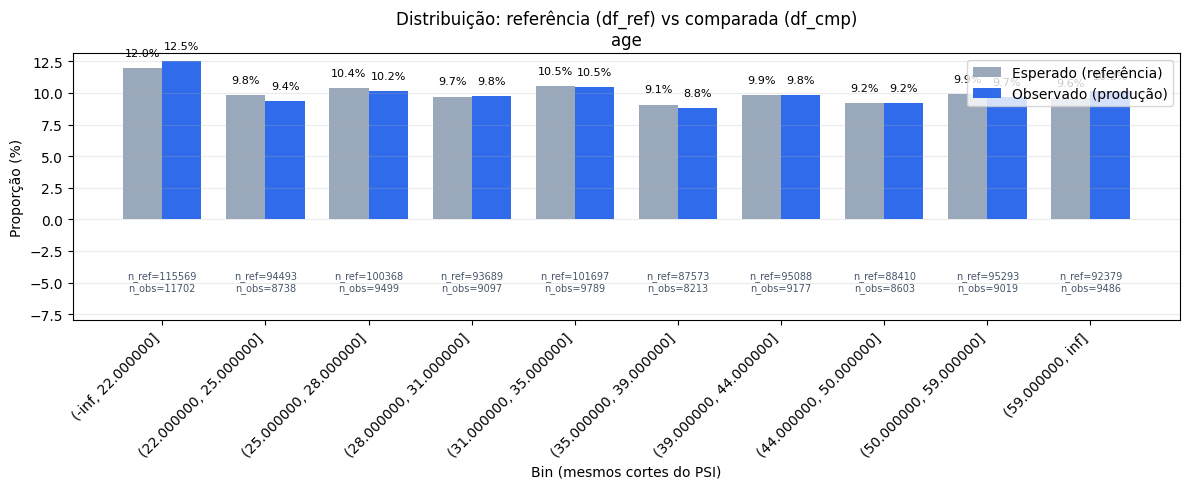

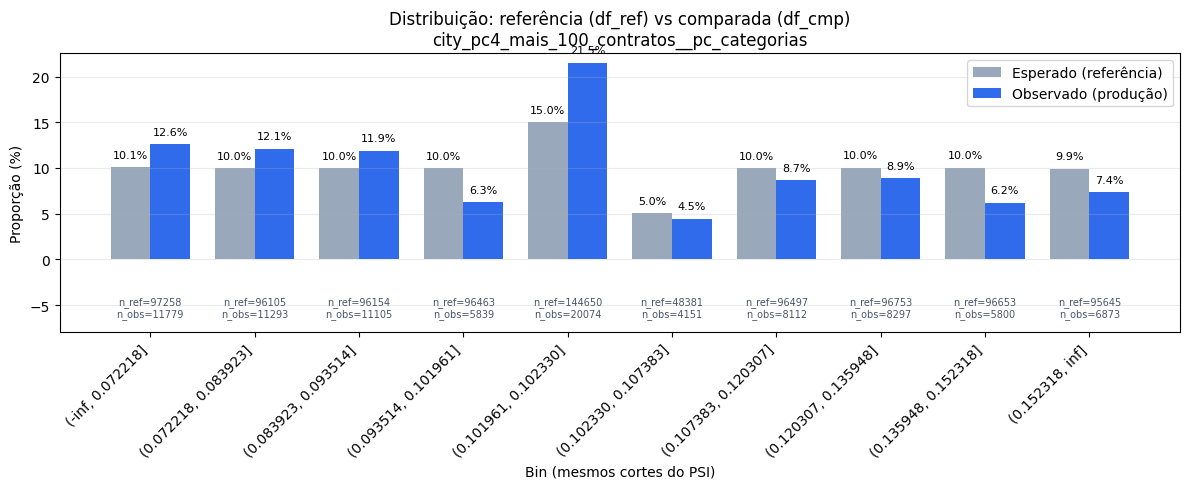

In [ ]:
import pandas as pd
import numpy as np
from funcoes_escoragem import prepare_blend4_variables
from funcoes_psi import (
    build_psi_reference_artifact,
    build_distribution_comparison,
    calculate_psi_from_reference,
    plot_variable_distribution,
    plot_distribution_comparison,
)

VARS = ["rental_value", "income", "income_commitment", "age", "city_pc4_mais_100_contratos__pc_categorias"]
N_DECIS = 10

# 1) Garantir income_commitment nas duas bases
# Se df/df_predict ainda não passaram pelo prepare, faça:
# df_ref = prepare_blend4_variables(df.copy())
# df_cmp = prepare_blend4_variables(df_predict.copy())

df_ref = df.copy()
df_cmp = df_prod[df_prod["income"] > 0].copy()

# Se income_commitment não existir:
for d in (df_ref, df_cmp):
    if "income_commitment" not in d.columns:
        d["income_commitment"] = d["rental_value"] / d["income"]
        d["income_commitment"] = d["income_commitment"].replace([np.inf, -np.inf], np.nan)

# 2) Criar deciles na referência e congelar os cortes
artifact = build_psi_reference_artifact(
    df_reference=df_ref,
    variables=VARS,
    n_bins=N_DECIS,
)

# 3) Ver min/max de cada decil (cortes congelados)
for var in VARS:
    spec = artifact["variables"][var]
    edges = spec["edges"]
    print(f"\n=== {var} ===")
    for i in range(len(edges) - 1):
        print(f"Decil {i+1:02d}: ({edges[i]:.4f}, {edges[i+1]:.4f}]")

# 4) Comparar distribuição referência vs comparada (mesmos cortes)
comparison_tables = {}
psi_rows = []

for var in VARS:
    spec = artifact["variables"][var]

    # Tabela por decil
    cmp_df = build_distribution_comparison(df_cmp[var], spec)
    cmp_df.insert(0, "variable", var)
    comparison_tables[var] = cmp_df

    # PSI resumindo o desvio total
    psi = calculate_psi_from_reference(df_cmp[var], spec)
    psi_rows.append({"variable": var, "psi": psi})

display(pd.concat(comparison_tables.values(), ignore_index=True))
display(pd.DataFrame(psi_rows))

# 5) Gráficos
for var in VARS:
    plot_variable_distribution(
        df_actual=df_cmp,
        artifact=artifact,
        variable=var,
        title="Distribuição: referência (df_ref) vs comparada (df_cmp)",
        show_counts=True,
    )

In [ ]:
for var in ["rental_value", "income", "income_commitment", "city_pc4_mais_100_contratos__pc_categorias"]:
    edges = artifact["variables"][var]["edges"]
    print(f"\n=== {var} ===")
    for i in range(len(edges) - 1):
        print(f"Decil {i+1:02d}: ({edges[i]:.4f}, {edges[i+1]:.4f}]")


=== rental_value ===
Decil 01: (-inf, 840.0000]
Decil 02: (840.0000, 1050.0000]
Decil 03: (1050.0000, 1207.5000]
Decil 04: (1207.5000, 1365.0000]
Decil 05: (1365.0000, 1575.0000]
Decil 06: (1575.0000, 1732.5000]
Decil 07: (1732.5000, 2016.0000]
Decil 08: (2016.0000, 2488.5000]
Decil 09: (2488.5000, 3265.5000]
Decil 10: (3265.5000, inf]

=== income ===
Decil 01: (-inf, 1575.5000]
Decil 02: (1575.5000, 1849.5000]
Decil 03: (1849.5000, 2260.5000]
Decil 04: (2260.5000, 2877.0000]
Decil 05: (2877.0000, 3836.0000]
Decil 06: (3836.0000, 4589.5000]
Decil 07: (4589.5000, 5685.5000]
Decil 08: (5685.5000, 8014.5000]
Decil 09: (8014.5000, 13494.5000]
Decil 10: (13494.5000, inf]

=== income_commitment ===
Decil 01: (-inf, 0.1274]
Decil 02: (0.1274, 0.2020]
Decil 03: (0.2020, 0.2705]
Decil 04: (0.2705, 0.3429]
Decil 05: (0.3429, 0.4229]
Decil 06: (0.4229, 0.5132]
Decil 07: (0.5132, 0.6271]
Decil 08: (0.6271, 0.7771]
Decil 09: (0.7771, 1.0451]
Decil 10: (1.0451, inf]

=== city_pc4_mais_100_contratos

In [ ]:
df_ref[VARS].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
rental_value,964559.0,1924.498164,1449.515413,1.050000,840.000000,1050.000000,1207.500000,1365.000000,1575.000000,1732.500000,2016.000000,2488.500000,3265.500000,20895.000000
income,964559.0,7310.812823,13050.017738,479.500000,1575.500000,1849.500000,2260.500000,2877.000000,3836.000000,4589.500000,5685.500000,8014.500000,13494.500000,184881.500000
income_commitment,964559.0,0.536164,0.481497,0.000028,0.127450,0.202010,0.270502,0.342874,0.422854,0.513170,0.627074,0.777068,1.045123,15.671341
age,964559.0,37.758577,14.268551,0.000000,22.000000,25.000000,28.000000,31.000000,35.000000,39.000000,44.000000,50.000000,59.000000,89.000000
city_pc4_mais_100_contratos__pc_categorias,964559.0,0.109737,0.033855,0.009709,0.072218,0.083923,0.093514,0.101961,0.102330,0.107383,0.120307,0.135948,0.152318,0.270270


In [ ]:
df_cmp[VARS].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
rental_value,93323.0,2.625381e+09,8.020187e+11,1.350000,900.000000,1100.000000,1300.000000,1450.000000,1600.000000,1800.000000,2200.000000,2600.000000,3500.000000,2.450072e+14
income,93323.0,7.461642e+03,1.507266e+04,479.500000,1507.000000,1781.000000,2192.000000,2740.000000,3630.500000,4452.500000,5548.500000,7877.500000,13289.000000,2.192685e+05
income_commitment,93323.0,4.913679e+05,1.501064e+08,0.000033,0.136092,0.217746,0.295251,0.374827,0.464499,0.567721,0.695169,0.862641,1.167883,4.585573e+10
age,93323.0,3.794324e+01,1.460938e+01,0.000000,22.000000,25.000000,28.000000,31.000000,35.000000,39.000000,44.000000,50.000000,60.000000,9.600000e+01
city_pc4_mais_100_contratos__pc_categorias,93323.0,1.029980e-01,2.962183e-02,0.000000,0.068966,0.079385,0.087515,0.097576,0.102330,0.102330,0.107708,0.124402,0.145669,2.269503e-01


In [ ]:
100*(2620.598274/1924.498164 - 1)

In [ ]:
100*(7538.733080/7310.812823 - 1)

In [ ]:
df_cmp["income"].describe()

## Variável-Cidade: city_pc4_mais_100_contratos__pc_categorias

In [ ]:
project_id = 'loft-dl-datascience'

query = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
'''

df_city = pd.read_gbq(query, project_id=project_id)
df_city

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,3522307,0.028125
1,2025-12-01,5003702,0.030303
2,2025-12-01,4216206,0.033113
3,2025-12-01,5008305,0.036496
4,2025-12-01,3500105,0.039216
...,...,...,...
1517,2026-07-01,3122306,0.183969
1518,2026-07-01,3533908,0.189091
1519,2026-07-01,2800308,0.193676
1520,2026-07-01,5107602,0.198630


In [ ]:
df_dev_blend4[["city_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
city_pc4_mais_100_contratos__pc_categorias,825215.0,0.110987,0.036454,0.009709,0.069715,0.08132,0.08963,0.097378,0.104139,0.115183,0.12513,0.140281,0.157096,0.27027


In [ ]:
df_prod[["city_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
city_pc4_mais_100_contratos__pc_categorias,110224.0,0.103213,0.029339,0.0,0.069444,0.079492,0.087515,0.097576,0.10233,0.10233,0.107708,0.125544,0.144354,0.22695


In [ ]:
var = "city_pc4_mais_100_contratos__pc_categorias"
percentiles = [.1, .2, .3, .4, .5, .6, .7, .8, .9]

summary = (
    df_city.groupby("mes_referencia")[var]
    .describe(percentiles=percentiles)
    .round(4)
)

display(summary)

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
mes_referencia,,,,,,,,,,,,,,
2025-12-01,182.0,0.1140,0.0439,0.0281,0.0587,0.0780,0.0883,0.0981,0.1107,0.1214,0.1345,0.1470,0.1684,0.2535
2026-01-01,186.0,0.1104,0.0435,0.0096,0.0596,0.0745,0.0825,0.0973,0.1067,0.1150,0.1315,0.1462,0.1652,0.2468
2026-02-01,188.0,0.1058,0.0438,0.0156,0.0589,0.0701,0.0794,0.0907,0.1020,0.1139,0.1253,0.1434,0.1587,0.2774
2026-03-01,191.0,0.1001,0.0428,0.0066,0.0552,0.0672,0.0747,0.0853,0.0943,0.1063,0.1209,0.1361,0.1553,0.2568
2026-04-01,194.0,0.0968,0.0406,0.0136,0.0512,0.0647,0.0719,0.0830,0.0919,0.1036,0.1152,0.1274,0.1504,0.2671
2026-05-01,192.0,0.0954,0.0379,0.0145,0.0516,0.0635,0.0735,0.0836,0.0900,0.0979,0.1122,0.1246,0.1459,0.2378
2026-06-01,195.0,0.0948,0.0376,0.0076,0.0509,0.0634,0.0730,0.0794,0.0907,0.0977,0.1117,0.1270,0.1458,0.2270
2026-07-01,194.0,0.0965,0.0374,0.0156,0.0557,0.0655,0.0747,0.0823,0.0888,0.1006,0.1120,0.1241,0.1472,0.2254


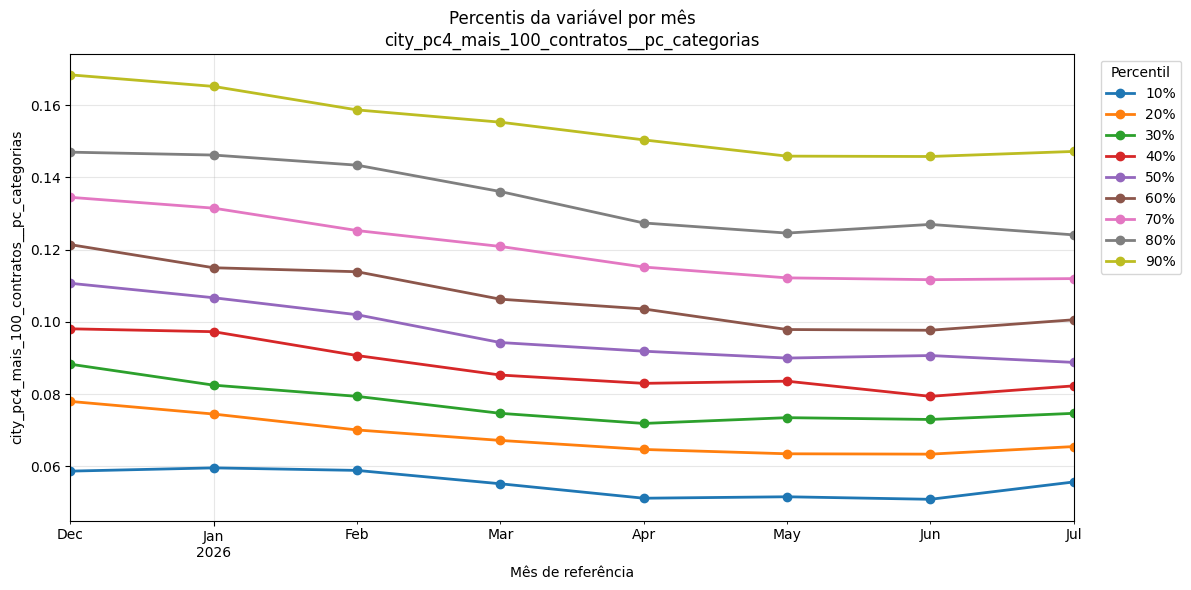

In [ ]:
percentile_cols = [f"{p}%" for p in range(10, 100, 10)]  # ['10%', '20%', ..., '90%']

plot_df = summary[percentile_cols].copy()
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

ax = plot_df.plot(
    figsize=(12, 6),
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Mês de referência")
ax.set_ylabel(var)
ax.set_title(f"Percentis da variável por mês\n{var}")
ax.grid(alpha=0.3)
ax.legend(title="Percentil", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# df_prod["safra"] = df_prod["requested_at"].astype(str).str[:7]
df_prod.groupby(df_prod["requested_at"].astype(str).str[:7]).size()

requested_at
2026-06    71952
2026-07    38272
dtype: int64

In [ ]:
df_city[pd.to_datetime(df_city["mes_referencia"]).dt.normalize() == "2026-07-01"]

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
1328,2026-07-01,5008305,0.015625
1329,2026-07-01,2507507,0.017544
1330,2026-07-01,3521408,0.018349
1331,2026-07-01,3504008,0.019737
1332,2026-07-01,3534708,0.034247
...,...,...,...
1517,2026-07-01,3122306,0.183969
1518,2026-07-01,3533908,0.189091
1519,2026-07-01,2800308,0.193676
1520,2026-07-01,5107602,0.198630


In [ ]:
df_prod[pd.to_datetime(df_prod["requested_at"].astype(str).str[:7]).dt.normalize() == "2026-07"]

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,age__normalized4_1,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4
728,13178756990,4316273,2026-07-01,2026-07-01,1,B,BLEND3_3,6026288,37,13178756990,...,-0.50,0.0,1.282758,0.0,0.128657,0.553087,447.0,B,D,8.C
729,9430522973,4316326,2026-07-01,2026-07-01,1,E,HVA4,6026389,32,9430522973,...,0.00,8.0,0.140992,0.0,0.866431,0.602967,397.0,D,NaN,10.D
730,1913404994,4316346,2026-07-01,2026-07-01,1,C,HVA4,6026375,32,1913404994,...,0.70,0.0,-0.562744,0.0,-0.707458,0.497495,503.0,A,NaN,7.B
731,4747831380,4316407,2026-07-01,2026-07-01,1,NI,BLEND3_3,6026446,33,4747831380,...,0.00,0.0,0.000000,0.0,1.430449,0.560942,439.0,C,NaN,9.D+
732,8614706995,4316538,2026-07-01,2026-07-01,1,E,BLEND3_3,6026605,33,8614706995,...,0.00,0.0,0.000000,0.0,-0.828362,0.482079,518.0,A,NaN,7.B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110463,86978113506,4354657,2026-07-09,2026-07-09,1,A,BLEND3_3,6074317,34,86978113506,...,1.35,0.0,0.278741,0.0,-0.578440,0.483517,516.0,A,A,7.B
110464,3251842080,4354681,2026-07-09,2026-07-09,1,NI,BLEND3_3,6074343,34,3251842080,...,0.00,0.0,0.323191,0.0,0.000000,0.498263,502.0,A,C,7.B
110465,2811305904,4354719,2026-07-09,2026-07-09,1,C,BLEND3_3,6074392,34,2811305904,...,0.65,0.0,-0.165325,0.0,-1.001829,0.471657,528.0,A,A,6.B
110466,5290711775,4354915,2026-07-09,2026-07-09,1,NI,BLEND3_3,6074634,31,5290711775,...,0.55,0.0,-0.861357,0.0,-1.178492,0.449490,551.0,A,A,6.B


In [ ]:
[col for col in df_prod.columns if "ibge" in col]

['request_imovel_codigo_cidade_ibge']

In [ ]:
df_prod[pd.to_datetime(df_prod["requested_at"].astype(str).str[:7]).dt.normalize() == "2026-07"][["requested_at", "request_imovel_codigo_cidade_ibge", "city_pc4_mais_100_contratos__pc_categorias"]]

,requested_at,request_imovel_codigo_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
728,2026-07-01,4113700.0,0.107107
729,2026-07-01,4208203.0,0.134499
730,2026-07-01,4106902.0,0.076064
731,2026-07-01,2211001.0,0.155440
732,2026-07-01,4218707.0,0.071575
...,...,...,...
110463,2026-07-09,4205407.0,0.080854
110464,2026-07-09,4311627.0,0.102330
110465,2026-07-09,4125506.0,0.065134
110466,2026-07-09,3304557.0,0.058575


In [ ]:
df_city_jul_ref = df_city[pd.to_datetime(df_city["mes_referencia"]).dt.normalize() == "2026-07-01"]
df_city_jul_ref.rename(columns={"city_pc4_mais_100_contratos__pc_categorias": "city_pc4_mais_100_contratos__pc_categorias_ref"}, inplace=True)

df_city_jul_prod = df_prod[pd.to_datetime(df_prod["requested_at"].astype(str).str[:7]).dt.normalize() == "2026-07"][["contract_id", "requested_at", "request_imovel_codigo_cidade_ibge", "city_pc4_mais_100_contratos__pc_categorias", "city_pc4_mais_100_contratos__pc_categorias_is_null"]]
df_city_jul_prod.rename(columns={"city_pc4_mais_100_contratos__pc_categorias": "city_pc4_mais_100_contratos__pc_categorias_prod"}, inplace=True)
df_city_jul_prod.rename(columns={"request_imovel_codigo_cidade_ibge": "id_cidade_ibge"}, inplace=True)

df_merge = pd.merge(df_city_jul_ref, df_city_jul_prod, on="id_cidade_ibge", how="left")
df_merge

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias_ref,contract_id,requested_at,city_pc4_mais_100_contratos__pc_categorias_prod,city_pc4_mais_100_contratos__pc_categorias_is_null
0,2026-07-01,5008305,0.015625,4333950,2026-07-06,0.015625,0
1,2026-07-01,5008305,0.015625,4337655,2026-07-06,0.015625,0
2,2026-07-01,5008305,0.015625,4354961,2026-07-09,0.015625,0
3,2026-07-01,5008305,0.015625,4339175,2026-07-06,0.015625,0
4,2026-07-01,5008305,0.015625,4324138,2026-07-02,0.102330,1
...,...,...,...,...,...,...,...
31429,2026-07-01,4313300,0.225352,4316526,2026-07-01,0.226950,0
31430,2026-07-01,4313300,0.225352,4321603,2026-07-01,0.226950,0
31431,2026-07-01,4313300,0.225352,4318917,2026-07-01,0.226950,0
31432,2026-07-01,4313300,0.225352,4331793,2026-07-03,0.225352,0


In [ ]:
df_city_jul_prod[df_city_jul_prod["requested_at"] != "2026-07-01"].groupby("id_cidade_ibge").agg(
    pc4_min=("city_pc4_mais_100_contratos__pc_categorias_prod", "min"),
    pc4_max=("city_pc4_mais_100_contratos__pc_categorias_prod", "max"),
)

,pc4_min,pc4_max
id_cidade_ibge,,
1100049.0,0.102330,0.10233
1100122.0,0.102330,0.10233
1100205.0,0.102330,0.10233
1100304.0,0.102330,0.10233
1200401.0,0.102330,0.10233
...,...,...
5220108.0,0.102330,0.10233
5220454.0,0.102330,0.10233
5221403.0,0.102330,0.10233


In [ ]:
df_city_jul_prod[df_city_jul_prod["id_cidade_ibge"] == 5300108.0]

,contract_id,requested_at,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias_prod,city_pc4_mais_100_contratos__pc_categorias_is_null
800,4323108,2026-07-02,5300108.0,0.060096,0
883,4330965,2026-07-03,5300108.0,0.060096,0
1013,4344491,2026-07-07,5300108.0,0.060096,0
1036,4347289,2026-07-08,5300108.0,0.060096,0
1928,4331733,2026-07-03,5300108.0,0.060096,0
...,...,...,...,...,...
109009,4321897,2026-07-01,5300108.0,0.102330,1
109060,4326858,2026-07-02,5300108.0,0.102330,1
109313,4353297,2026-07-09,5300108.0,0.060096,0
110283,4336591,2026-07-06,5300108.0,0.060096,0


In [ ]:
df_city_jul_prod[
    (df_city_jul_prod["id_cidade_ibge"] == 5300108.0)
    & (df_city_jul_prod["city_pc4_mais_100_contratos__pc_categorias_prod"] == 0)
].sort_values("city_pc4_mais_100_contratos__pc_categorias_prod")

,contract_id,requested_at,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias_prod,city_pc4_mais_100_contratos__pc_categorias_is_null


In [ ]:
df_city[df_city["id_cidade_ibge"] == 5300108.0]

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
27,2025-12-01,5300108,0.071681
221,2026-01-01,5300108,0.075530
414,2026-02-01,5300108,0.074266
597,2026-03-01,5300108,0.068702
789,2026-04-01,5300108,0.066849
984,2026-05-01,5300108,0.065759
1173,2026-06-01,5300108,0.064203
1356,2026-07-01,5300108,0.060096


In [ ]:
df_merge[
    (df_merge["city_pc4_mais_100_contratos__pc_categorias_ref"].notna())
    & (df_merge["city_pc4_mais_100_contratos__pc_categorias_prod"].round(3) != df_merge["city_pc4_mais_100_contratos__pc_categorias_ref"].round(3))
    & (df_merge["city_pc4_mais_100_contratos__pc_categorias_prod"] == 0)
].groupby("requested_at").size()

Series([], dtype: int64)

In [ ]:
df_merge[
    (df_merge["city_pc4_mais_100_contratos__pc_categorias_ref"].notna())
    & (df_merge["city_pc4_mais_100_contratos__pc_categorias_prod"].round(3) == df_merge["city_pc4_mais_100_contratos__pc_categorias_ref"].round(3))
    & (df_merge["city_pc4_mais_100_contratos__pc_categorias_prod"] == 0)
].groupby("requested_at").size()

Series([], dtype: int64)

## Variável-Imobiliária: agency_pc4_mais_100_contratos__pc_categorias

In [ ]:
project_id = 'loft-dl-datascience'

query = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_imobiliaria
'''

df_agency = pd.read_gbq(query, project_id=project_id)
df_agency

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,9706,0.019417
1,2025-12-01,1399,0.021429
2,2025-12-01,4420,0.024390
3,2025-12-01,4926,0.026738
4,2025-12-01,9418,0.028571
...,...,...,...
1150,2026-07-01,10656,0.274336
1151,2026-07-01,4249,0.275591
1152,2026-07-01,25913,0.284810
1153,2026-07-01,3419,0.286853


In [ ]:
df_dev_blend4[["agency_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
agency_pc4_mais_100_contratos__pc_categorias,189702.0,0.144897,0.078544,0.013245,0.066496,0.087379,0.1,0.115385,0.130682,0.144404,0.164706,0.189911,0.226667,0.542373


In [ ]:
df_prod[["agency_pc4_mais_100_contratos__pc_categorias"]].describe(percentiles=[.1,.2, .3, .4,.5,.6, .7, .8, .9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
agency_pc4_mais_100_contratos__pc_categorias,110224.0,0.131292,0.026194,0.0,0.12931,0.12931,0.12931,0.12931,0.12931,0.12931,0.12931,0.12931,0.12931,0.405172


In [ ]:
var = "agency_pc4_mais_100_contratos__pc_categorias"
percentiles = [.1, .2, .3, .4, .5, .6, .7, .8, .9]

summary = (
    df_agency.groupby("mes_referencia")[var]
    .describe(percentiles=percentiles)
    .round(4)
)

display(summary)

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
mes_referencia,,,,,,,,,,,,,,
2025-12-01,129.0,0.1437,0.0821,0.0194,0.0601,0.0783,0.0925,0.1152,0.1274,0.1502,0.1764,0.1965,0.2253,0.4732
2026-01-01,133.0,0.1411,0.0771,0.0091,0.0518,0.0792,0.0973,0.1125,0.1338,0.1451,0.1771,0.2013,0.2275,0.4417
2026-02-01,146.0,0.1335,0.0718,0.0085,0.0524,0.0755,0.0960,0.1094,0.1197,0.1429,0.1590,0.1875,0.2167,0.4375
2026-03-01,149.0,0.1245,0.0618,0.0000,0.0538,0.0748,0.0916,0.1044,0.1205,0.1314,0.1479,0.1667,0.1976,0.3475
2026-04-01,154.0,0.1253,0.0625,0.0000,0.0511,0.0737,0.0886,0.1046,0.1160,0.1338,0.1554,0.1680,0.2012,0.3448
2026-05-01,150.0,0.1255,0.0641,0.0000,0.0526,0.0728,0.0877,0.1037,0.1177,0.1345,0.1524,0.1683,0.2085,0.3421
2026-06-01,151.0,0.1241,0.0661,0.0000,0.0522,0.0680,0.0854,0.1017,0.1108,0.1280,0.1429,0.1679,0.2174,0.4052
2026-07-01,143.0,0.1265,0.0634,0.0185,0.0602,0.0715,0.0887,0.1024,0.1130,0.1289,0.1467,0.1733,0.2241,0.3548


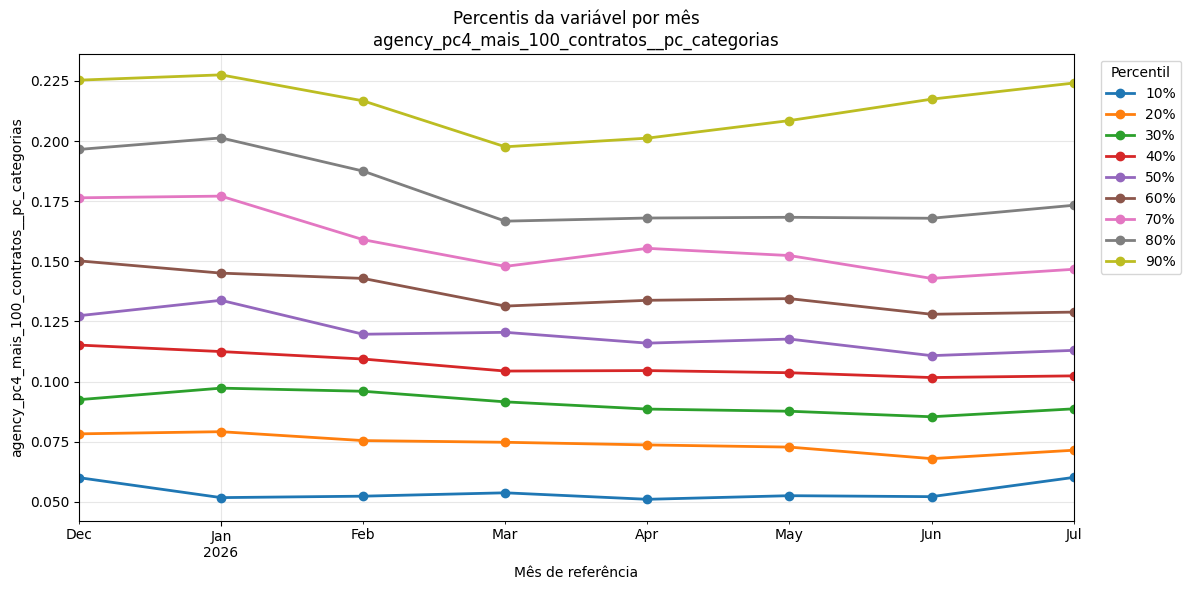

In [ ]:
percentile_cols = [f"{p}%" for p in range(10, 100, 10)]  # ['10%', '20%', ..., '90%']

plot_df = summary[percentile_cols].copy()
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

ax = plot_df.plot(
    figsize=(12, 6),
    marker="o",
    linewidth=2,
)
ax.set_xlabel("Mês de referência")
ax.set_ylabel(var)
ax.set_title(f"Percentis da variável por mês\n{var}")
ax.grid(alpha=0.3)
ax.legend(title="Percentil", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Aluguel ao longo de 2025/2026

In [58]:
project_id = 'loft-dl-fintech'

query = '''
SELECT
id_imovel AS contract_id,
CAST(vl_aluguel AS FLOAT64) AS rental_value,
DATE(data) AS requested_at
FROM `loft-dl-fintech.bronze_credpago.historico_valor`
WHERE DATE(data) >= DATE('2025-01-01')
QUALIFY ROW_NUMBER() OVER (PARTITION BY id_imovel ORDER BY data DESC) = 1
'''

df_rental_value = pd.read_gbq(query, project_id=project_id)

In [59]:
df_rental_value

,contract_id,rental_value,requested_at
0,7511,852.32,2025-01-03
1,14510,1724.39,2026-05-17
2,37621,2528.17,2026-02-05
3,45180,3030.49,2025-04-03
4,54215,1725.50,2025-06-13
...,...,...,...
2447239,4010840,5000.00,2026-04-13
2447240,4010949,5000.00,2026-04-13
2447241,4031593,5000.00,2026-04-17
2447242,4121001,5000.00,2026-05-12


In [65]:
VARS = ["rental_value"]

df_rental_value["safra"] = df_rental_value["requested_at"].astype(str).str[:7]
plot_percentiles_by_month(df_rental_value, date_col="safra", dataset_name="df_rental_value")

KeyError: 'income'